Plot saved as correlation_phase_transition.png


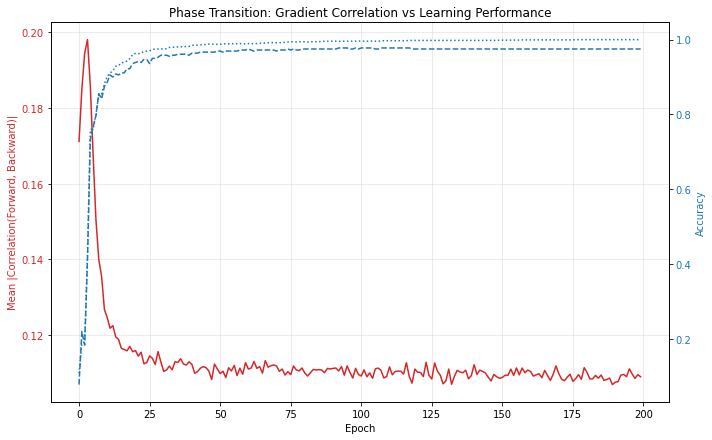

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Prepare Data
digits = load_digits()
X = digits.data
y = digits.target

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
enc = OneHotEncoder()
Y_onehot = enc.fit_transform(y.reshape(-1, 1)).toarray()

X_train, X_test, y_train, y_test = train_test_split(X, Y_onehot, test_size=0.2, random_state=42)

# 2. Define Numpy MLP
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.softmax(self.z2)
        return self.a2

    def backward(self, X, y, return_correlation=False):
        m = X.shape[0]
        
        # Output layer error (Cross Entropy + Softmax)
        dz2 = self.a2 - y
        dw2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        
        # Hidden layer error
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.sigmoid_derivative(self.a1)
        
        # This is where we measure the correlation
        # We are interested in the update for W1: delta_w1 ~ X.T * dz1
        # Specifically, for a weight w_ij connecting input i to hidden j:
        # gradient_sample_k = X[k, i] * dz1[k, j]
        # We want to check correlation(X[:, i], dz1[:, j])
        
        avg_corr = 0
        if return_correlation:
            # We will sample a subset of weights to compute correlation to save time
            # Or compute full correlation matrix if dimensions allow (64 inputs * 32 hidden = 2048 pairs)
            
            # Normalize X and dz1 to compute correlation efficiently
            # Corr(A, B) = Mean((A - meanA)(B - meanB)) / (StdA * StdB)
            
            # Let's take the first hidden neuron j=0 and compute correlation with all inputs i
            # To be more robust, we average over all hidden neurons and all inputs
            
            # Centering
            X_centered = X - X.mean(axis=0)
            dz1_centered = dz1 - dz1.mean(axis=0)
            
            # Covariance matrix (Input x Hidden)
            covariance = np.dot(X_centered.T, dz1_centered) / m
            
            # Std devs
            X_std = X.std(axis=0).reshape(-1, 1) + 1e-8
            dz1_std = dz1.std(axis=0).reshape(1, -1) + 1e-8
            
            correlation_matrix = covariance / np.dot(X_std, dz1_std)
            avg_corr = np.mean(np.abs(correlation_matrix))

        # Update weights
        dw1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        
        self.W1 -= self.lr * dw1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dw2
        self.b2 -= self.lr * db2
        
        return avg_corr

# 3. Training Loop
input_size = X.shape[1]
hidden_size = 64
output_size = Y_onehot.shape[1]

model = MLP(input_size, hidden_size, output_size, learning_rate=0.1)

epochs = 200
correlations = []
accuracies = []
train_accuracies = []

batch_size = 32

for epoch in range(epochs):
    # Shuffle
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    epoch_corrs = []
    
    # Mini-batch training
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        model.forward(X_batch)
        # Compute correlation only for the last batch of the epoch or average over batches
        # Let's average over batches
        corr = model.backward(X_batch, y_batch, return_correlation=True)
        epoch_corrs.append(corr)
    
    # Record metrics
    correlations.append(np.mean(epoch_corrs))
    
    # Test Accuracy
    y_pred_test = model.forward(X_test)
    acc = np.mean(np.argmax(y_pred_test, axis=1) == np.argmax(y_test, axis=1))
    accuracies.append(acc)
    
    # Train Accuracy
    y_pred_train = model.forward(X_train)
    train_acc = np.mean(np.argmax(y_pred_train, axis=1) == np.argmax(y_train, axis=1))
    train_accuracies.append(train_acc)

# 4. Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean |Correlation(Forward, Backward)|', color=color)
ax1.plot(range(epochs), correlations, color=color, label='Signal Correlation')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Accuracy', color=color)  # we already handled the x-label with ax1
ax2.plot(range(epochs), accuracies, color=color, linestyle='--', label='Test Accuracy')
ax2.plot(range(epochs), train_accuracies, color=color, linestyle=':', label='Train Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Phase Transition: Gradient Correlation vs Learning Performance')
plt.savefig('correlation_phase_transition.png')
print("Plot saved as correlation_phase_transition.png")